# 5.5.2 有限样本分箱与信息偏差

## 学习目标与先修知识

能按明确边界构造联合计数、比较嵌套分箱（binning）的离散信息量；用重复独立样本识别插件偏差，限定观测（observation）价值结论。

先修：上一节的熵（entropy）和互信息（mutual information），5.1 的重复实验与分位数。 [复习上一节](01-熵与互信息的离散定义.ipynb)。

## 具体问题

两个传感器在模型（model）中完全独立，为什么从少量数据算出的互信息经常大于零？将每个轴分成更多箱，是发现了更多信息还是制造了更稀疏的表？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
example=np.array([[3,1],[1,3]])
print('有限样本表：',example.tolist())
print('边缘乘积对应的频数：',np.outer(example.sum(axis=1),example.sum(axis=0))/example.sum())

有限样本表： [[3, 1], [1, 3]]
边缘乘积对应的频数： [[2. 2.]
 [2. 2.]]


## 模型假设

X、Y 相互独立且各在 [0,1] 上连续均匀，真实互信息为零。分箱边界预先固定为等宽 2 箱或 8 箱，两种编码嵌套；最后一箱含最右端点。每个 n=40、400 各做 B=200 次；随机种子（random seed）为 5502，各次重复独立抽样。同一批样本对照两种分箱，以免更换数据混淆比较。

## 数学解释与推导

先把连续读数映射为箱号 B，再求 B 的离散熵与互信息。普通箱为 [eᵢ,eᵢ₊₁)，最后一个包含最右端点；内部边界归右箱。频数 Cᵢⱼ 除以 N 得到经验概率（probability），再代入熵和互信息公式，称为插件估计（plug-in estimator）。

即使真实变量独立，有限表也常不满足 $\hat p_{ij}=\hat p_i\hat p_j$。插件互信息非负，且通常不恰为零，因此独立情形会出现正的平均估计偏差。稀疏箱越多，未观察格越多；把零频数当作零真概率也会造成熵估计偏差。不进行额外校正的数值必须连同样本量、分箱和重复波动解释。

对固定分布（distribution），确定性粗化不能增加互信息。一个说明是把粗箱标签 C 看作细标签 B 的函数：知道 B 已经包含 C，链式分解 I(X;B)=I(X;C)+I(X;B|C)，条件互信息逐条件非负。对 X、Y 两侧先后粗化得到结果。该结论也适用于同一张经验表，但细表更高的值并不说明它更接近未知真实值。不嵌套分箱没有简单按箱数排序的保证。

分箱标签的熵不自动等于连续变量的微分熵。更换读数单位时还要同步更换边界。比较通道时应预先固定样本量与编码，报告重复范围和独立机制参照，不从最大一次结果挑结论。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def bin_pairs(xs, ys, edges):
    import bisect
    n = len(edges)-1
    counts = [[0]*n for _ in range(n)]
    for x,y in zip(xs,ys):
        i = min(bisect.bisect_right(edges,x)-1,n-1)
        j = min(bisect.bisect_right(edges,y)-1,n-1)
        counts[i][j] += 1
    return counts


def information(counts):
    import math
    total = sum(map(sum, counts))
    joint = [[c/total for c in row] for row in counts]
    px = list(map(sum,joint))
    py = [sum(row[j] for row in joint) for j in range(len(joint[0]))]
    hx = -sum(p*math.log2(p) for p in px if p>0)
    hy = -sum(p*math.log2(p) for p in py if p>0)
    mi = sum(p*math.log2(p/(px[i]*py[j])) for i,row in enumerate(joint) for j,p in enumerate(row) if p>0)
    return hx, hy, mi


def information(counts):
    import math
    total = sum(map(sum, counts))
    joint = [[c/total for c in row] for row in counts]
    px = list(map(sum,joint))
    py = [sum(row[j] for row in joint) for j in range(len(joint[0]))]
    hx = -sum(p*math.log2(p) for p in px if p>0)
    hy = -sum(p*math.log2(p) for p in py if p>0)
    mi = sum(p*math.log2(p/(px[i]*py[j])) for i,row in enumerate(joint) for j,p in enumerate(row) if p>0)
    return hx, hy, mi


def compare_information(coarse_counts, fine_counts):
    return information(coarse_counts), information(fine_counts)

## 对照实验

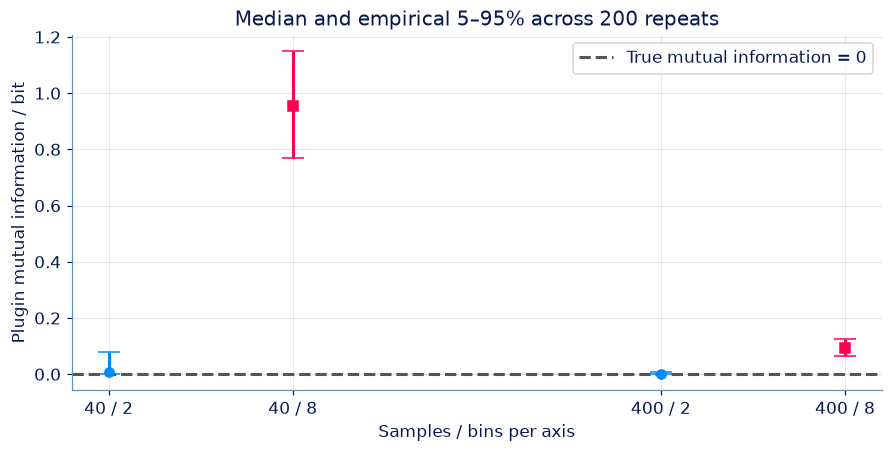

| n | 箱数 | 均值 | 5% | 50% | 95% | 均值的 Monte Carlo 标准误 |
| --- | --- | --- | --- | --- | --- | --- |
| 40 | 2 | 0.0180413 | 4.53109e-06 | 0.0061486 | 0.0805713 | 0.00199788 |
| 40 | 8 | 0.951452 | 0.770101 | 0.955632 | 1.15045 | 0.00835468 |
| 400 | 2 | 0.00176816 | 1.80369e-05 | 0.00088705 | 0.00717849 | 0.00017929 |
| 400 | 8 | 0.0931818 | 0.0635122 | 0.0924946 | 0.126456 | 0.00141497 |

上表信息量单位 bit；根种子 5502 ；B= 200 ；PCG64；NumPy 2.5.3


In [4]:
sizes=[40,400];bins=[2,8];repeats=200;root_seed=5502
streams=np.random.SeedSequence(root_seed).spawn(400);estimates=np.zeros((2,2,repeats))
for j,n in enumerate(sizes):
    for b in range(repeats):
        rng=np.random.Generator(np.random.PCG64(streams[j*repeats+b]));xs=rng.random(n);ys=rng.random(n)
        for k,nbins in enumerate(bins):
            counts=bin_pairs(xs.tolist(),ys.tolist(),np.linspace(0,1,nbins+1).tolist())
            estimates[j,k,b]=information(counts)[2]
fig,ax=plt.subplots();rows=[]
for j,n in enumerate(sizes):
    for k,nbins in enumerate(bins):
        v=estimates[j,k];lo,med,hi=np.quantile(v,[.05,.5,.95]);position=j*3+k
        ax.errorbar(position,med,yerr=[[med-lo],[hi-med]],fmt=['o','s'][k],color=[BLUE,PINK][k],capsize=7)
        rows.append((n,nbins,v.mean(),lo,med,hi,v.std(ddof=1)/np.sqrt(repeats)))
ax.axhline(0,color=GRAY,ls='--',label='True mutual information = 0')
ax.set(xticks=[0,1,3,4],xticklabels=['40 / 2','40 / 8','400 / 2','400 / 8'],xlabel='Samples / bins per axis',ylabel='Plugin mutual information / bit',title='Median and empirical 5–95% across 200 repeats');ax.legend();plt.show()
display(Markdown(show_table(['n','箱数','均值','5%','50%','95%','均值的 Monte Carlo 标准误'],rows)))
print('上表信息量单位 bit；根种子',root_seed,'；B=',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

真实信息为零，经验值仍可明显偏正；细箱、小样本组合的偏差尤其明显。图的范围是估计值在重复实验间的波动，表中标准误（standard error）描述其平均值的 Monte Carlo 精度。在这个已知独立的例子里，正的估计值来自有限样本偏差。

### 独立核对

使用可手算的嵌套表检查编码；总体独立性由抽样机制规定，提供信息零值参照。样本量之间的平均比较只陈述本次固定实验结果。

In [5]:
assert bin_pairs([0,.5,1],[1,.5,0],[0,.5,1])==[[0,1],[1,1]]
assert np.all(estimates>=-1e-12)
assert np.all(estimates[:,1]>=estimates[:,0]-1e-12)  # same sample, nested bins
assert estimates[1,1].mean()<estimates[0,1].mean()
fine=[[1,0,1,0],[0,1,0,1],[1,0,1,0],[0,1,0,1]]
coarse=np.array(fine).reshape(2,2,2,2).sum(axis=(1,3))
np.testing.assert_allclose(compare_information(coarse.tolist(),fine),[[1,1,0],[2,2,1]])
print('边界归箱、总量粗化、信息不增与独立重复参照一致。')

边界归箱、总量粗化、信息不增与独立重复参照一致。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按显式边界统计联合频数

连续观测（observation）需要先分箱（binning）。本题两个变量使用相同 edges。返回行对应 xs、列对应 ys 的联合计数表。

**函数与代码模板**

```python
def solve(
    xs: list[float],
    ys: list[float],
    edges: list[float],
) -> list[list[int]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `xs` | `list[float]` | 第一通道配对样本。 | U |
| `ys` | `list[float]` | 第二通道配对样本。 | U |
| `edges` | `list[float]` | 严格递增分箱边界。 | U |

**返回值**

直接返回 counts（list[list[int]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `counts` | `list[list[int]]` | (len(edges)−1) 阶联合频数表。 | 次 |

**计算规则**

除最后一箱外均为左闭右开 [eᵢ,eᵢ₊₁)；最后一箱包含最右端点。恰在内部边界上的数进入右侧箱。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- xs、ys 等长，长度 1—100；2—9 个边界；所有样本在 [edges[0],edges[-1]]；数值绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| xs | 第一通道配对样本。 | [0, 0.5, 1] | U |
| ys | 第二通道配对样本。 | [1, 0.5, 0] | U |
| edges | 严格递增分箱边界。 | [0, 0.5, 1] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
xs = [0, 0.5, 1]
ys = [1, 0.5, 0]
edges = [0, 0.5, 1]

result = solve(xs, ys, edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| counts | (len(edges)−1) 阶联合频数表。 | [[0, 1], [1, 1]] | 次 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0, 1], [1, 1]]
```

**样例解释**

0 进第 0 箱，0.5 和 1 都进第 1 箱，所以联合表为 [[0,1],[1,1]]。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：按显式边界统计联合频数](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-bin-pairs)

### 第 2 题 · 多项选择题：独立通道为何估出正互信息

真实 X、Y 独立，但有限样本频数表算得互信息（mutual information） 0.08 bit。哪些正确？

- **A.** 可用独立机制的多次重复作为参照，并比较样本量。
- **B.** 再细分更多箱必然更接近真实连续信息量。
- **C.** 有限表通常不能精确分解成边缘概率（probability）的乘积，插件互信息会有波动和向上偏差。
- **D.** 已推翻独立假设，无需不确定性分析。

[作答：独立通道为何估出正互信息](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-finite-bias)

### 第 3 题 · 多项选择题：同一张表合并箱会怎样

细分箱（binning）经确定规则合并为粗分箱，使用完全相同的配对样本。哪些正确？

- **A.** 两个不嵌套分箱也必须按箱数严格排序。
- **B.** 经验分布（distribution）上的互信息（mutual information）不会因确定性合并增加（忽略舍入）。
- **C.** 细分后的更高互信息本身证明观测（observation）更有用。
- **D.** 粗化可能丢失区分信息。

[作答：同一张表合并箱会怎样](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-coarsening)

### 第 4 题 · 单项选择题：分箱熵属于哪个变量

将连续读数 Y 按固定边界编码为箱号 B，计算 H(B)。哪项正确？

- **A.** 它自动就是 Y 的微分熵（entropy）。
- **B.** 它是该分箱（binning）标签的离散熵，会随边界改变。
- **C.** 任何改变单位都不需同步改变边界。
- **D.** 箱数越多就证明物理机制越复杂。

[作答：分箱熵属于哪个变量](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-binning-units)

### 第 5 题 · 多项选择题：怎样比较两个测量通道

要用经验互信息（mutual information）比较两传感器。哪些应固定或同时报告？

- **A.** 预先定义的分箱（binning）规则。
- **B.** 只挑各通道最大的那次结果。
- **C.** 有限样本偏差参照与波动范围。
- **D.** 采样机制、样本量与重复次数。

[作答：怎样比较两个测量通道](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-comparison-budget)

**进一步阅读**

[MIT 6.441 讲义](https://ocw.mit.edu/courses/6-441-information-theory-spring-2016/pages/lecture-notes/)，第 1 章 §1.1 熵、第 2 章 §2.3 互信息、第 3 章 §3.1 数据处理。

[NumPy 随机子流文档](https://numpy.org/doc/stable/reference/random/parallel.html)：SeedSequence.spawn 的可复现派生。